# Task 3 : **TensorBoard training and evaluation graph analysis**

This notebook presents a visual analysis of the training and evaluation behaviour of the **Faster R-CNN ResNet-101** and **SSD** model using TensorBoard. The purpose of this analysis is to assess **model convergence, stability, and learning behaviour** during training.

---

## Launch TensorBoard from Python

This code opens **TensorBoard** in a new Command Prompt window and points it to the model’s training directory. TensorBoard is used to **visualise training logs**, such as loss curves, learning rate, and evaluation metrics. This code opens **TensorBoard** in a new Command Prompt window and points it to the model’s training directory. TensorBoard is used to **visualise training logs**, such as loss curves, learning rate, and evaluation metrics.


In [ ]:
import os

BASE_PATH = r"C:/Users/MSC1/Desktop/Tensorflow-Object-Detection-API/Base/v1/" # Adjust this path as needed
OBJECT_DETECTION_PATH = fr"{BASE_PATH}/object_detection/" # This is the path to the object_detection directory
MODEL_PATH = fr"{OBJECT_DETECTION_PATH}/training/TF2/training/faster_rcnn_resnet101_v1_1024x1024_coco17_tpu-8" # use this path for faster rcnn model
#MODEL_PATH = fr"{OBJECT_DETECTION_PATH}/training/TF2/training/ssd_resnet50_v1_fpn_640x640_coco17_tpu-8" # use this path for ssd model
os.system(f'start cmd /k tensorboard --logdir="{MODEL_PATH}" --port 6006') 


### Explanation

* `BASE_PATH`
  Defines the root directory of the TensorFlow Object Detection API.

* `MODEL_PATH`
  Points to the folder where training logs (`events.out.tfevents`) are saved.

* `tensorboard --logdir`
  Tells TensorBoard where to read training logs from.

* `--port 6006`
  Runs TensorBoard on port **6006** (default TensorBoard port).

* `start cmd /k`
  Opens TensorBoard in a **new Command Prompt window** and keeps it open.

### How to Access TensorBoard

After running the cell, open your browser and go to:

```
http://localhost:6006
```

You will be able to monitor **training loss, learning rate, and other metrics** in real time.

---

# 1. Model Training & TensorBoard Analysis (Faster R-CNN)

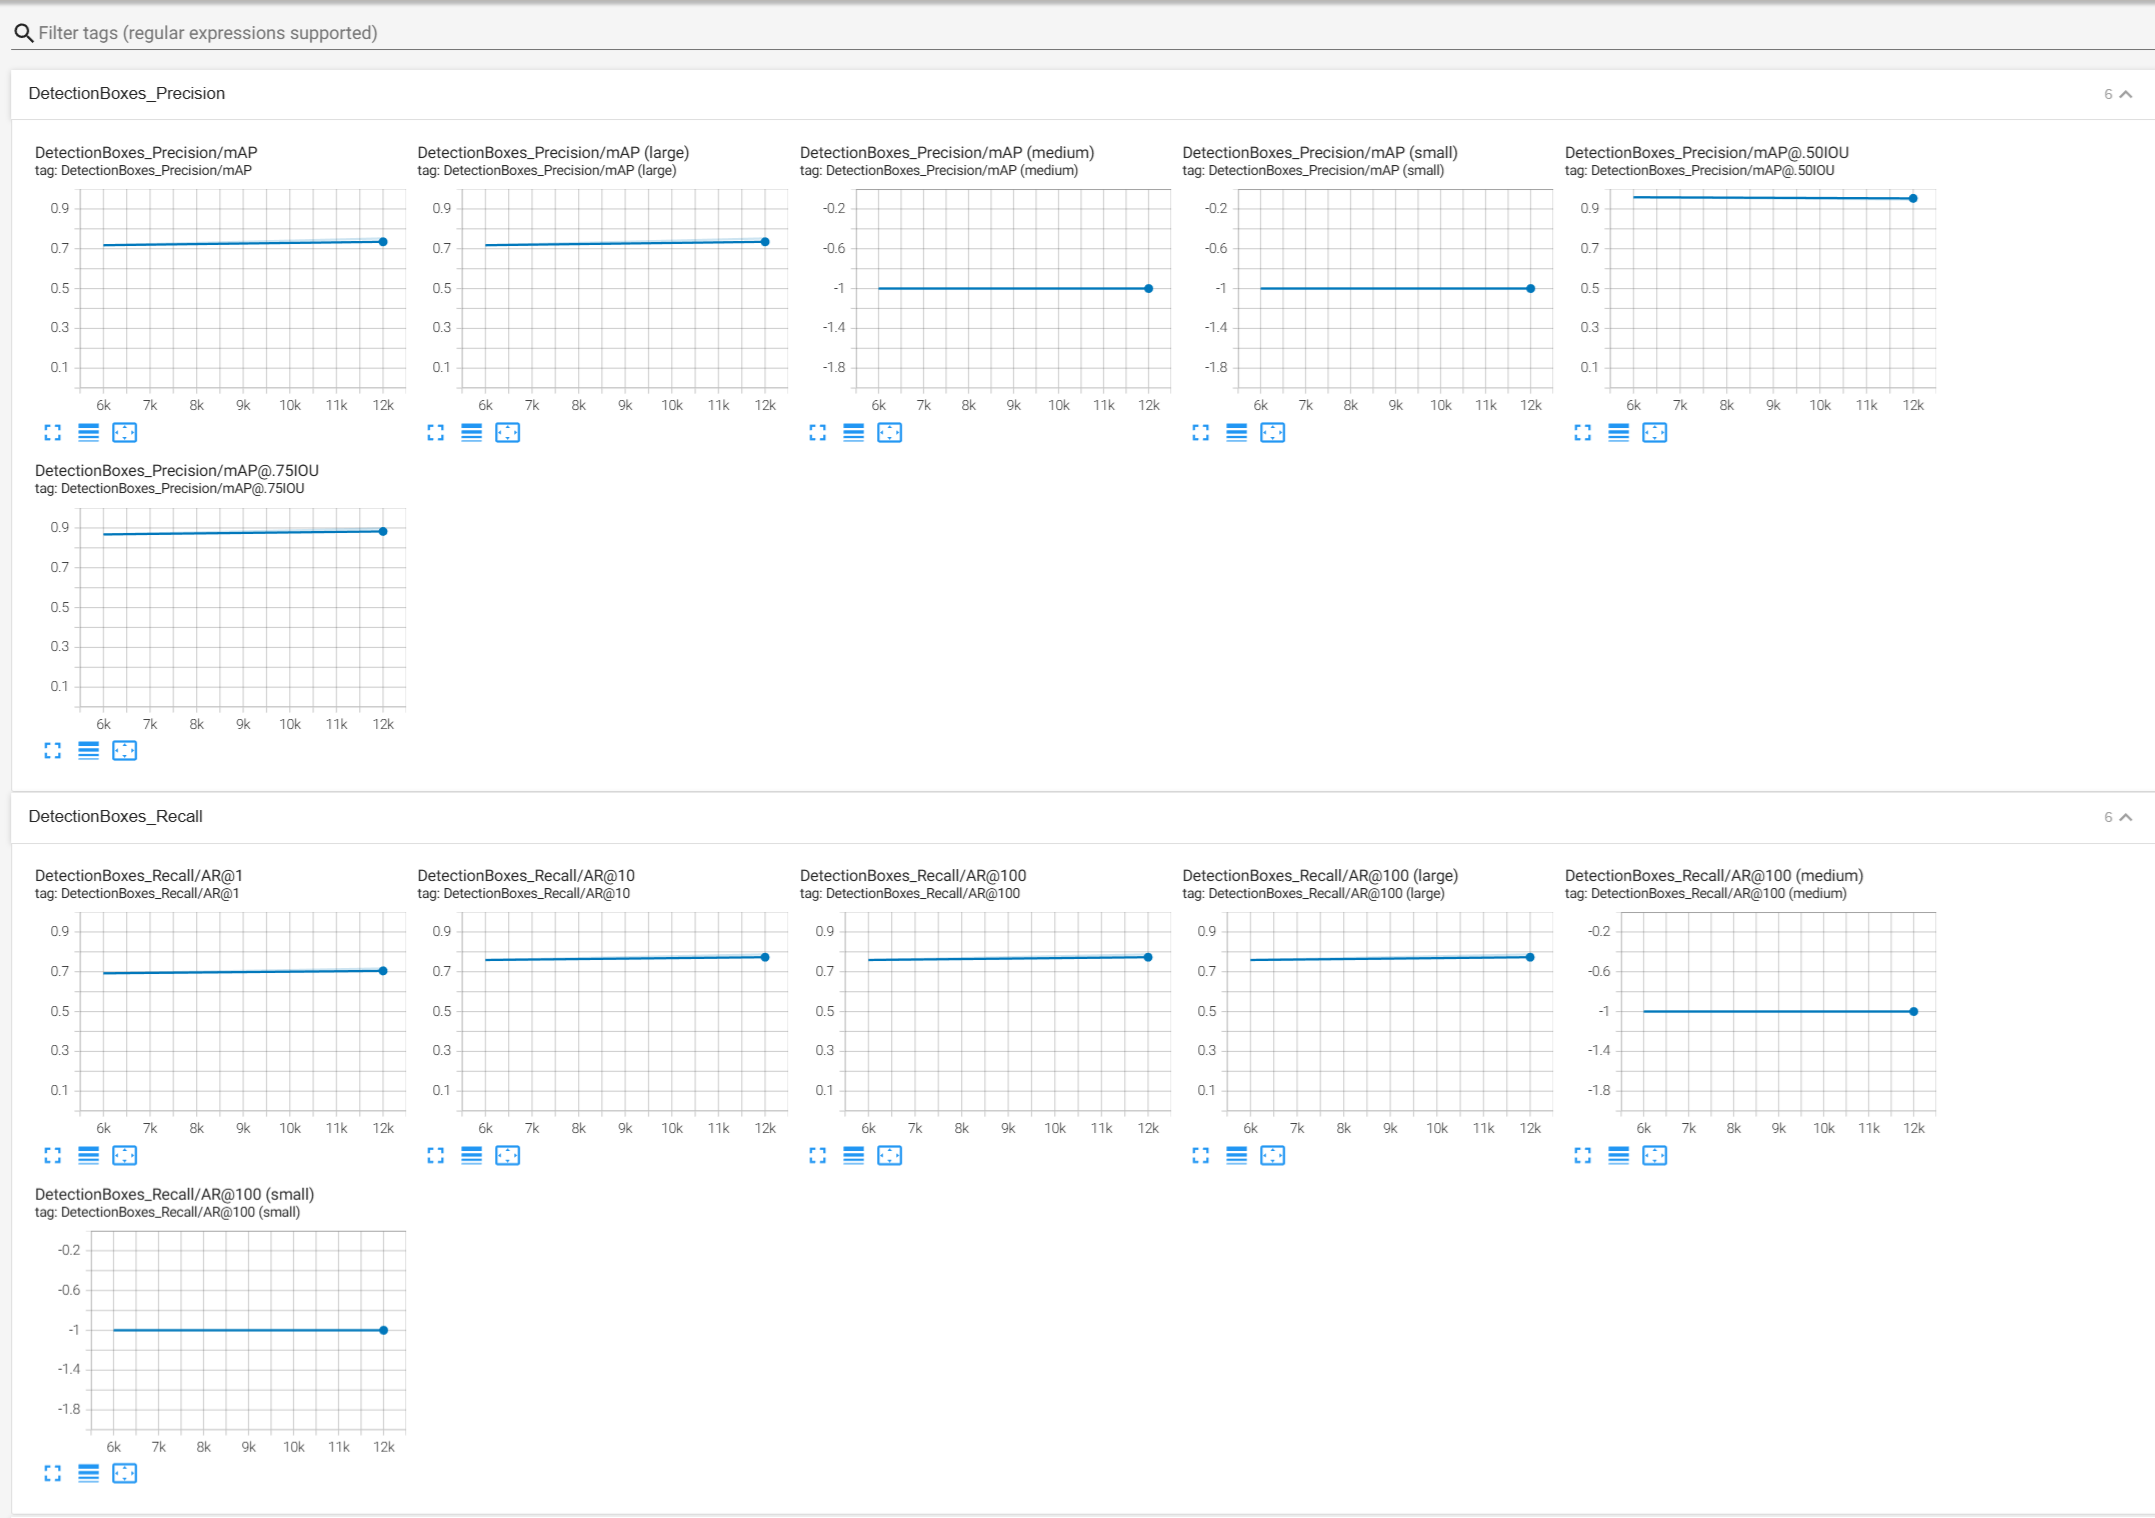

### **1. DetectionBoxes Precision (mAP)**

#### **mAP (Overall)**

The average mean Precision (mAP) is increasing progressively with the training and then begins to plateau on approximately **6000** steps. That is, the model continues to improve on locating objects and then maintains its level.

#### **mAP @ IoU = 0.50**

The mAP with an overlap threshold of 0.50 has a high number in the initial stages and remains constant. This demonstrates that the model is effective in locating objects when there is an intermediate overlap.

#### **mAP @ IoU = 0.75**

The mAP at the overlap threshold of 0.75 changes at a slower rate and ceases to vary after that. That is natural since a stiffer overlap will require the box to be more precise. The flat curve indicates that the model performs well when there is accuracy in placing the boxes.


#### **Small and Medium Object mAP**

The mAP values for small and medium objects remain at **-1.0** throughout training. This occurs because the dataset contains **only large objects**, and no ground-truth annotations exist for small or medium categories. This behaviour is expected and not an error.

#### **Large Object mAP**

The mAP of the large objects is at the same curve with the overall mAP, which demonstrates that the model is effective in predicting the main size of the objects in the data set.

---

### **2. DetectionBoxes Recall (AR)**

#### **AR @ 1, AR @ 10, AR @ 100**

The recall curves are also constant and improving with the number of boxes per image. It indicates that the model detects a majority of objects and misses a few.


#### **Large Object Recall**

Large object recall remains high and constant, and there is good large object size detection.

#### **Small and Medium Object Recall**

Similarly to precision, small and mediums objects have recall set to -1.0 since there are no such objects in the set of data.

---


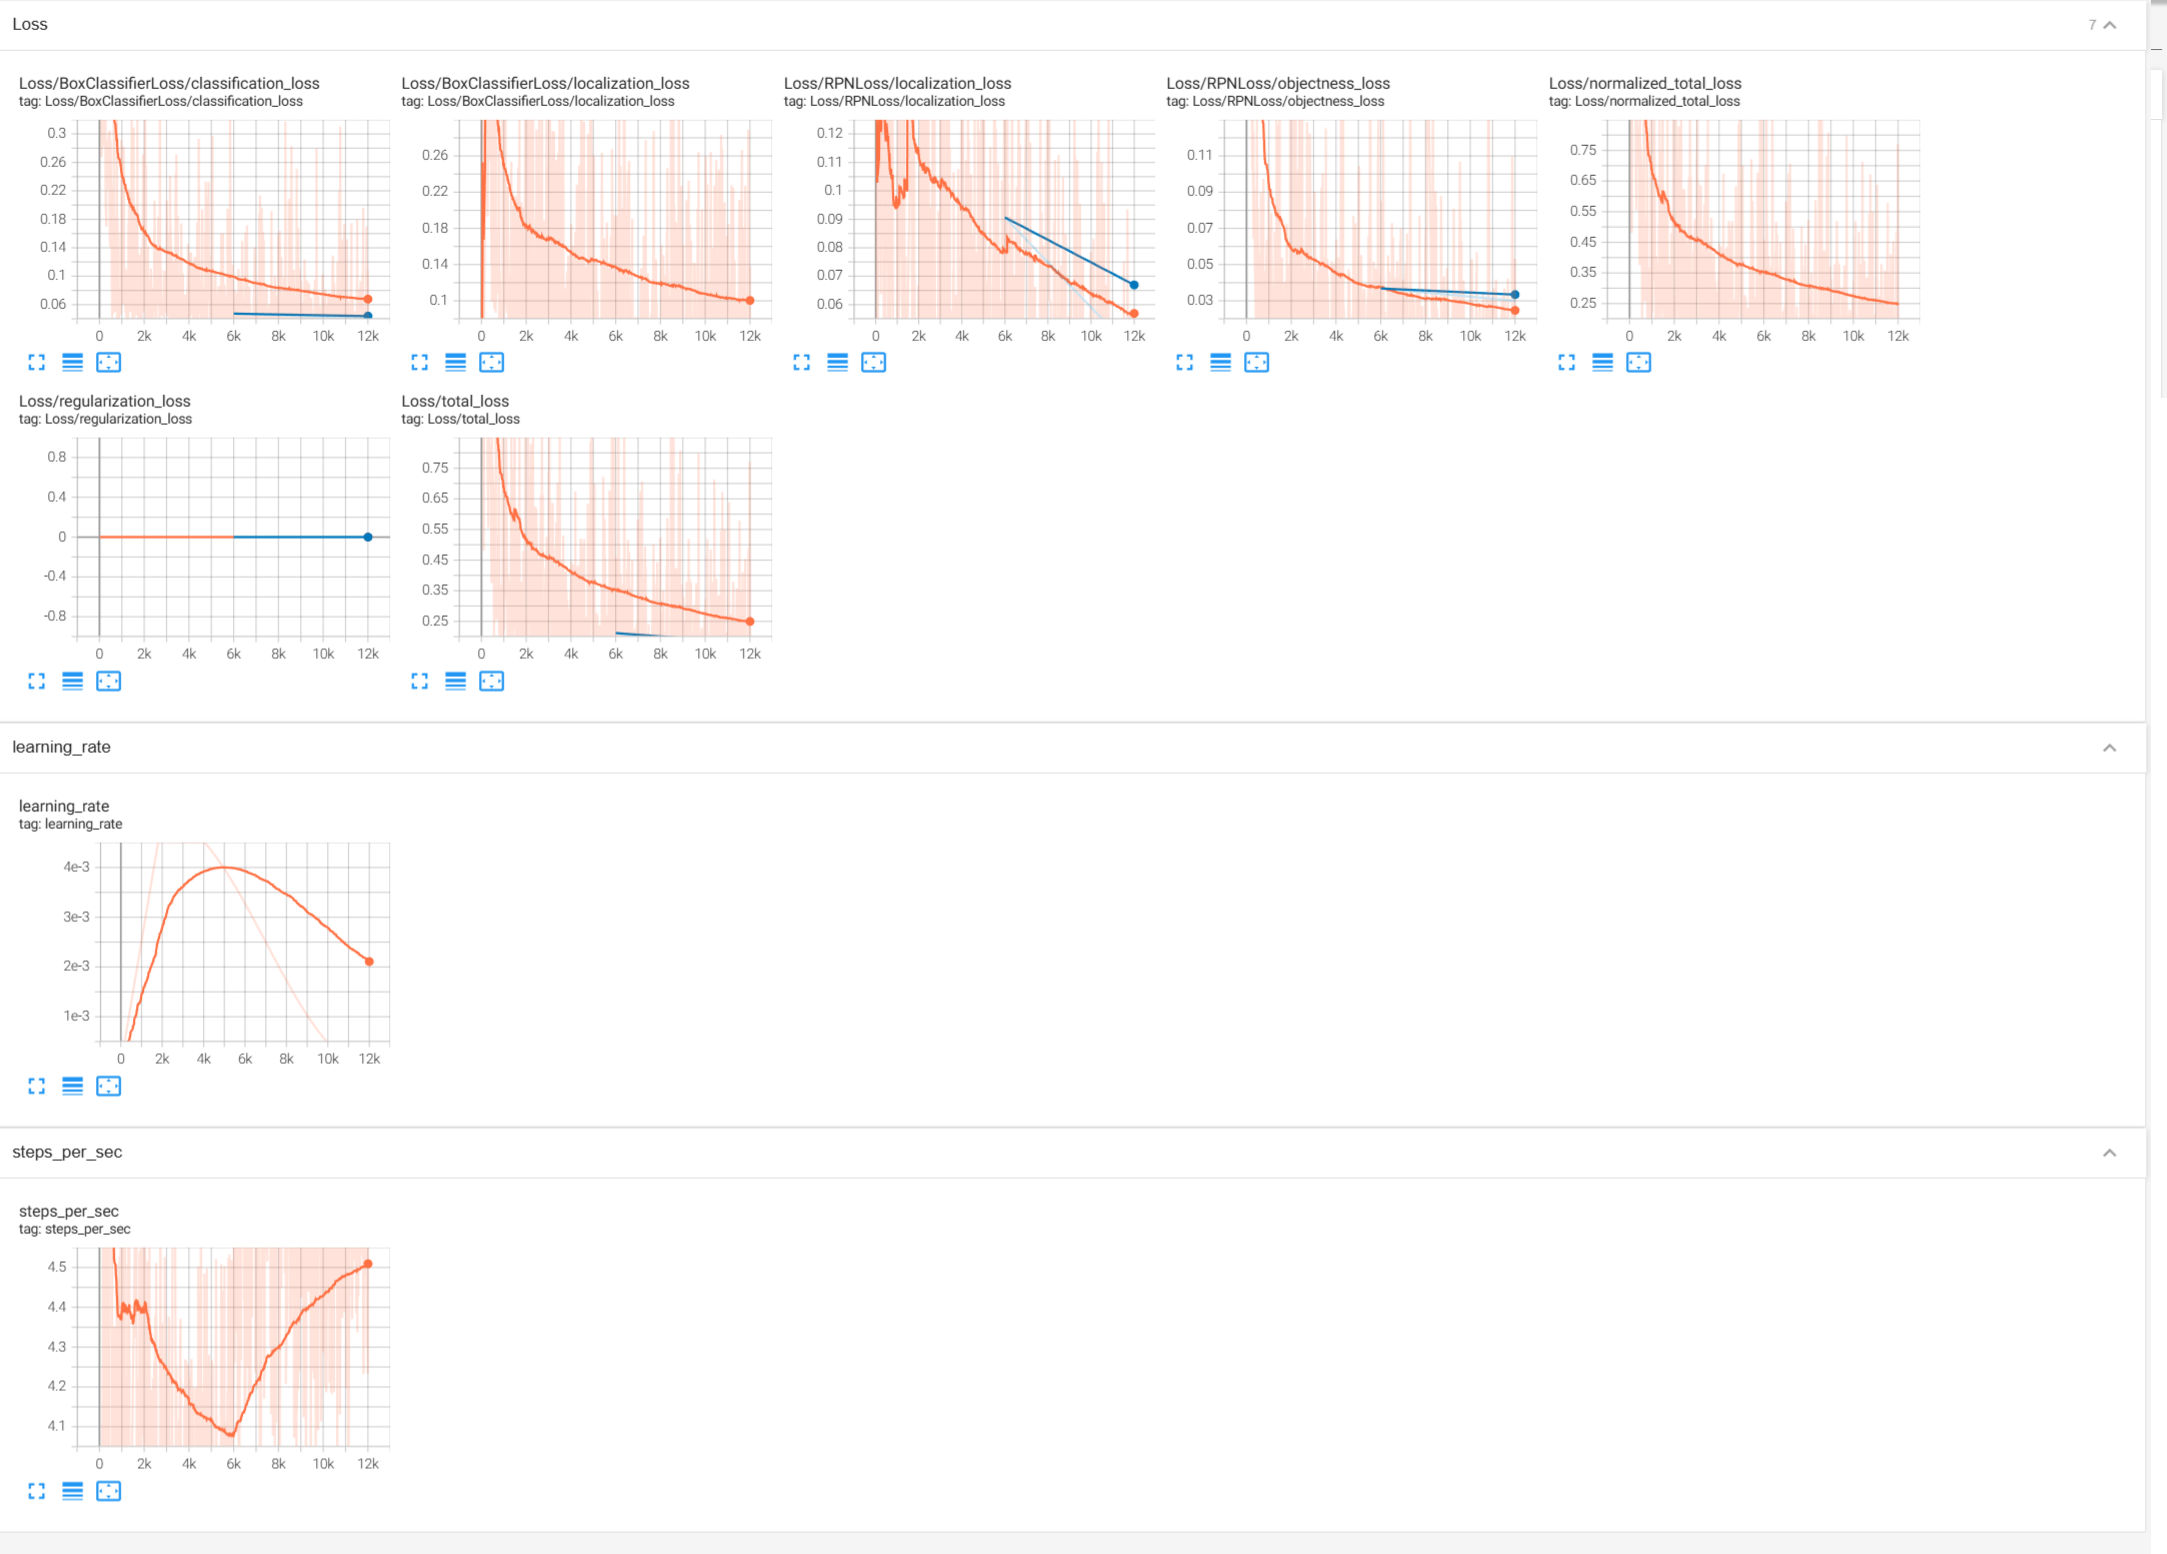


### **3. Loss Curves for tranning data**

#### **Box Classifier Classification Loss**

This loss decreases rapidly initially and becomes stable. This shows that the model is learning to correctly classify detected objects.

#### **Box Classifier Localization Loss**

The localisation loss decreases gradually, i.e. the box size prediction only gets better and better.

#### **RPN Localization Loss**

The RPN localisation loss reduces in a smooth manner indicating that the proposal network is taught to generate good candidate boxes.

#### **RPN Objectness Loss**

This loss decreases and stabilizes with time demonstrating that RPN learns to distinguish real objects and the background.

#### **Total Loss**

The overall loss continues to decrease and it eventually reaches a constant point after approximately 6000 steps, indicating that the training process has successfully completed.

---

### **4. Learning Rate Schedule**

The learning rate is based on a cosine decay with a warm-up. It increases gradually in the beginning to maintain the updates. Once it has peaked, it then has a gradual downfall so that fine optimisation and stable learning can occur.

---

### **5. Training Throughput (Steps per Second)**

There is a slight change in steps per second graph during training which is acceptable due to data loading and hardware variation. All in all the speed remains constant, with good utilization of resources.

---

### **6. Convergence Summary**

Based on the TensorBoard visualisations:

* The level of loss curves stabilizes at approximately **6000 training steps**
* Precision and recall metrics show minimal improvement beyond this point
* No signs of overfitting are observed

The following points demonstrate that the model has been processed, and the time spent on training is justified.

---


# 2 - Model Training & TensorBoard Analysis of SSD

---

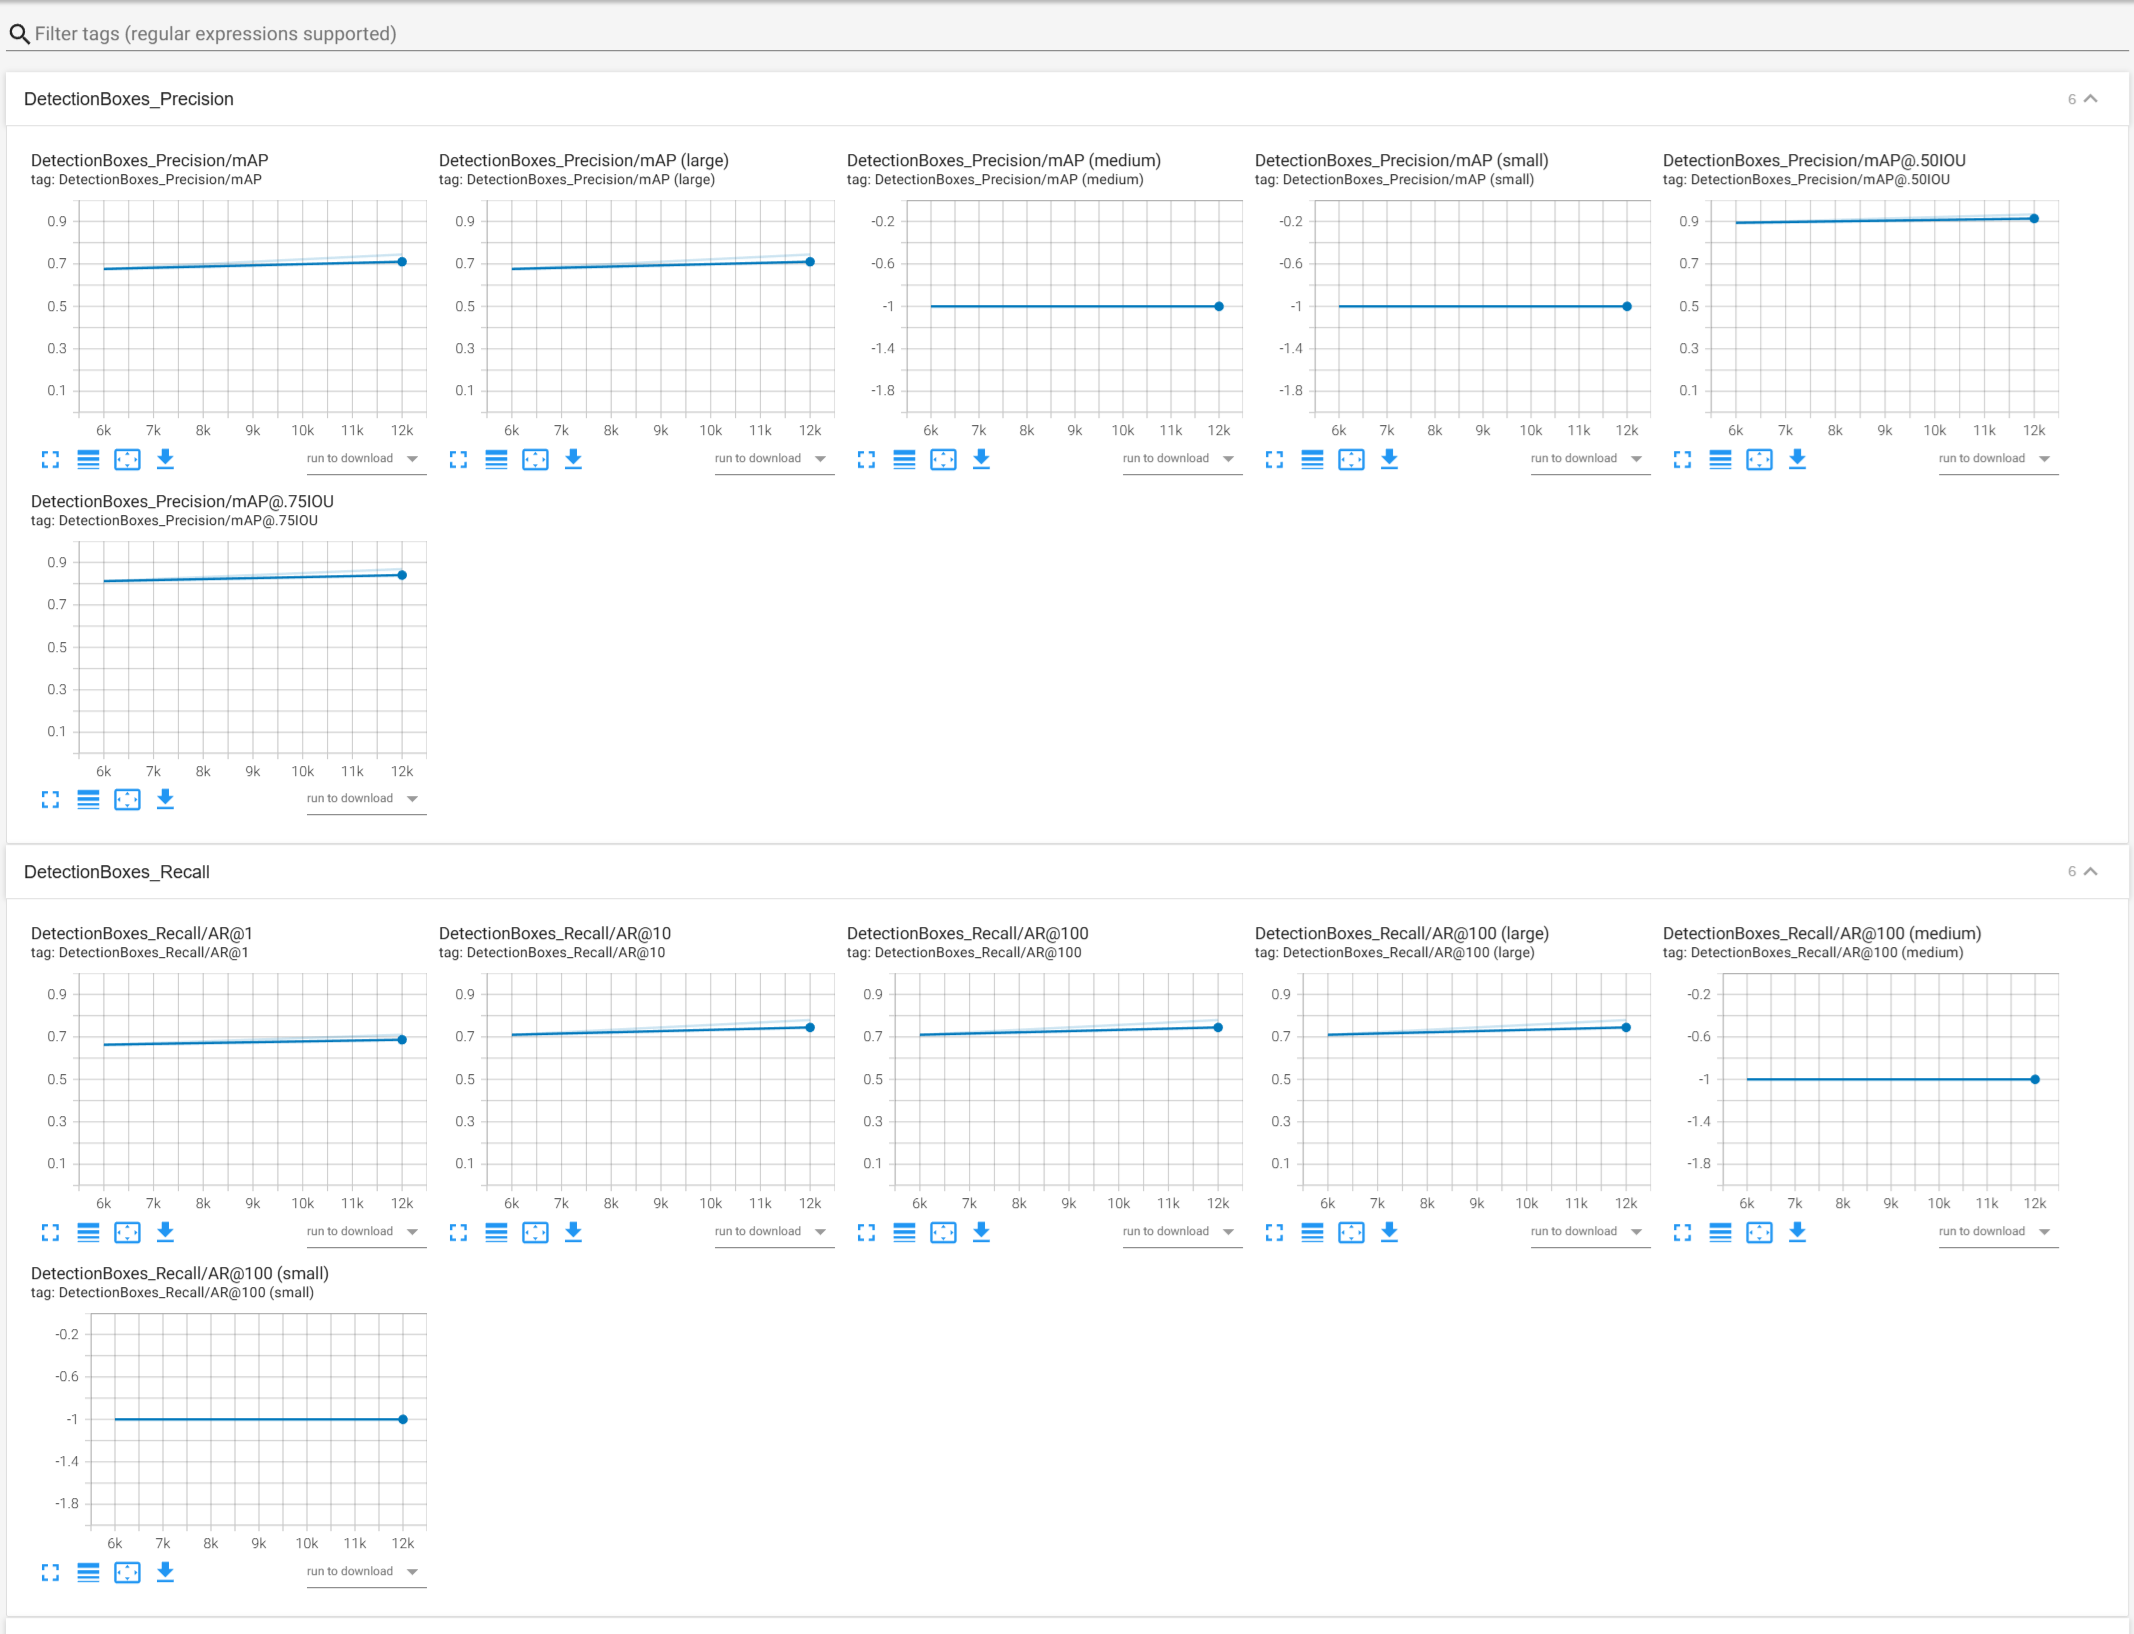

### **1. DetectionBoxes Precision (mAP)**

#### **Overall mAP**

The overall mean Average Precision (mAP) increases slowly from about **6000 to 12000 steps**.
The model was **evaluated after every 6000 training steps**. Although the training performance continued to improve, the **evaluation performance improved only slightly**.
This shows that further training was giving very small gains on validation data. Therefore, training was stopped to avoid unnecessary training and possible overfitting.

---

#### **mAP @ IoU = 0.50**

The mAP at **IoU = 0.50** is high from the beginning and improves slightly with training.
Even after additional training steps, the improvement in evaluation mAP is small, which suggests that the model had already learned most of the useful features for detection at this level.

---

#### **mAP @ IoU = 0.75**

The mAP at **IoU = 0.75** improves slowly and then becomes almost stable.
Although training continues to reduce loss, the evaluation performance shows only minor improvement.
This indicates that further training does not significantly improve bounding box precision.

---

#### **Small and Medium Object mAP**

The mAP for **small and medium objects remains at -1.0** throughout training.
This is expected because the dataset contains **only large objects**, and no ground-truth annotations exist for small or medium objects.

---

#### **Large Object mAP**

The mAP for **large objects follows the same trend as the overall mAP**.
This confirms that the SSD model mainly learns from large objects and performs well on the object sizes present in the dataset.

---

### **2. DetectionBoxes Recall (AR)**

#### **AR @ 1, AR @ 10, AR @ 100**

Recall improves slightly when more detections per image are allowed.
However, similar to precision, the **evaluation recall improves very slowly after every 6000 steps**, even though training performance keeps improving.
This suggests diminishing returns from continued training.

---

#### **Large Object Recall**

Recall for **large objects remains high and stable** during training.
This indicates that SSD consistently detects large objects and rarely misses them.

---

#### **Small and Medium Object Recall**

Recall for **small and medium objects remains at -1.0**.
This is expected because the dataset does not contain small or medium objects.

---

### **Overall Conclusion**

The SSD model shows stable and reliable performance on large objects.
Although training loss continued to improve, evaluation performance showed only small improvement after each 6000-step evaluation.
This indicates that the model was close to convergence, and further training could lead to overfitting.
Therefore, training was stopped at this stage to maintain good generalisation performance.


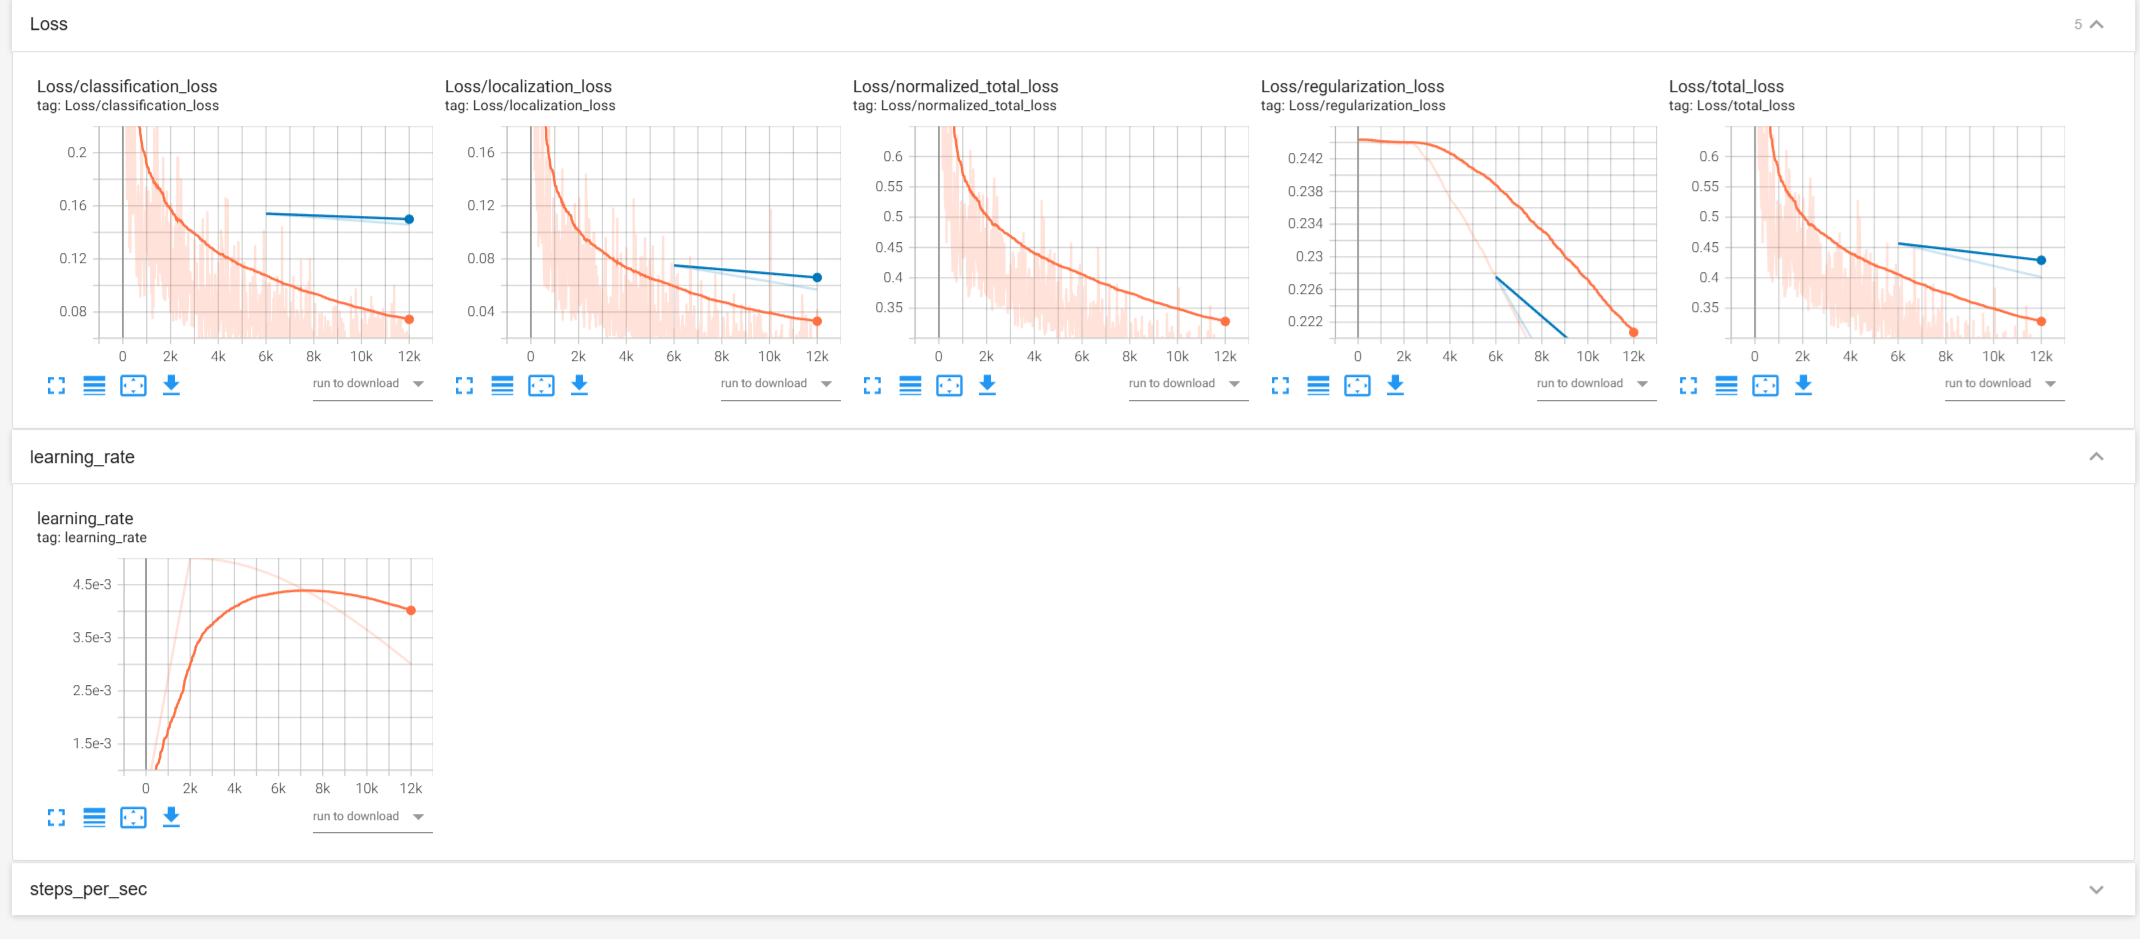

### **1. Classification Loss**

This loss shows how well the model is **classifying objects correctly**.
At the start, the classification loss is high, which means the model is making many class mistakes.
As training continues, the loss **steadily decreases**, showing that the model is learning to predict the correct class more accurately.
After around **6000 steps**, the loss still decreases but more slowly, meaning learning is happening but with smaller improvements.

---

### **2. Localization Loss**

Localization loss measures how well the model is **placing bounding boxes** around objects.
In the beginning, the loss is high because the predicted boxes are not well aligned with the ground truth.
Over time, the loss **clearly decreases**, which means the bounding boxes are becoming more accurate.
After 6000 steps, improvement continues but at a slower rate, showing diminishing returns.

---

### **3. Normalized Total Loss**

This loss is a **combined and scaled version** of all main losses.
It gives an overall picture of how well the model is learning.
The curve shows a **smooth and consistent decrease**, which means the training process is stable.
Later in training, the curve flattens, indicating that the model is close to convergence.

---

### **4. Regularization Loss**

Regularization loss helps prevent the model from **overfitting** by penalizing very large weights.
This loss decreases slowly and smoothly during training.
The gradual decrease shows that weight values are being controlled properly.
This indicates good generalisation behaviour and stable training.

---

### **5. Total Loss**

Total loss is the **sum of all losses** (classification, localization, and regularization).
At the start, the loss is high, but it **steadily decreases** as training progresses.
After about **6000 steps**, the loss still improves but only slightly.
This shows that while training continues to improve, the overall learning gain becomes smaller.

---

### **6. Learning Rate**

This graph shows how the **learning rate changes during training**.
At the beginning, the learning rate increases (warm-up phase), which helps stabilise early training.
Later, the learning rate slowly decreases, allowing the model to fine-tune its weights.
This learning rate schedule helps avoid sudden changes and supports stable convergence.

---

## **Overall Observation**

All loss curves decrease smoothly, which shows that the model is learning correctly.
However, after around **6000 steps**, training losses keep improving but **evaluation performance improves very little**.
This indicates that the model is close to convergence, so training was stopped to avoid overfitting and unnecessary computation.